In [7]:
import csv
from datetime import datetime

FILENAME = "fertilizer_inventory.csv"

# Create the CSV file with initial data if it doesn't exist
initial_data = [
    {'Fertilizer': 'Urea', 'Quantity': 1000, 'ExpiryDate': '2025-12', 'Price': 25.50},
    {'Fertilizer': 'DAP', 'Quantity': 500, 'ExpiryDate': '2026-06', 'Price': 30.00},
    {'Fertilizer': 'Potash', 'Quantity': 750, 'ExpiryDate': '2024-11', 'Price': 20.75}
]

try:
    with open(FILENAME, 'x', newline='') as file:
        fieldnames = ['Fertilizer', 'Quantity', 'ExpiryDate', 'Price']
        writer = csv.DictWriter(file, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(initial_data)
    print(f"Created '{FILENAME}' with initial data.")
except FileExistsError:
    print(f"'{FILENAME}' already exists. Skipping initial data creation.")

# 1. Read CSV file
def read_inventory():
    inventory = []
    with open(FILENAME, mode='r', newline='') as file:
        reader = csv.DictReader(file)
        for row in reader:
            row['Quantity'] = int(row['Quantity'])
            row['Price'] = float(row['Price'])
            inventory.append(row)
    return inventory

# 2. Update quantities
def update_quantity(inventory, fertilizer_name, change):
    for item in inventory:
        if item['Fertilizer'].lower() == fertilizer_name.lower():
            item['Quantity'] += change
            print(f"Updated {fertilizer_name} quantity to {item['Quantity']}")
            return
    print("Fertilizer not found")

# 3. Find expiring items
def find_expiring(inventory, before_date):
    print("\nExpiring Fertilizers:")
    for item in inventory:
        expiry = datetime.strptime(item['ExpiryDate'], "%Y-%m")
        if expiry <= before_date:
            print(item)

# 4. Write updated data back to CSV
def write_inventory(inventory):
    with open(FILENAME, mode='w', newline='') as file:
        fieldnames = ['Fertilizer', 'Quantity', 'ExpiryDate', 'Price']
        writer = csv.DictWriter(file, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(inventory)

# -------- MAIN PROGRAM --------
inventory = read_inventory()

update_quantity(inventory, "Urea", -50)

find_expiring(inventory, datetime(2026, 6, 1))

write_inventory(inventory)

print("\nInventory updated successfully.")

Created 'fertilizer_inventory.csv' with initial data.
Updated Urea quantity to 950

Expiring Fertilizers:
{'Fertilizer': 'Urea', 'Quantity': 950, 'ExpiryDate': '2025-12', 'Price': 25.5}
{'Fertilizer': 'DAP', 'Quantity': 500, 'ExpiryDate': '2026-06', 'Price': 30.0}
{'Fertilizer': 'Potash', 'Quantity': 750, 'ExpiryDate': '2024-11', 'Price': 20.75}

Inventory updated successfully.


In [8]:
# Import necessary libraries
import numpy as np
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Load built-in dataset
digits = load_digits()

# Input features (flattened 8x8 images → 64 features)
X = digits.data

# Target labels (0–9 digits)
y = digits.target

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale data for better neural network performance
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Build ANN model
model_ann = Sequential()
model_ann.add(Dense(64, activation='relu', input_shape=(64,)))
model_ann.add(Dense(32, activation='relu'))
model_ann.add(Dense(10, activation='softmax'))

# Compile model
model_ann.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

# Train model
model_ann.fit(X_train, y_train, epochs=20, batch_size=32, verbose=1)

# Evaluate model
y_pred = np.argmax(model_ann.predict(X_test), axis=1)

print("ANN Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.2283 - loss: 2.1960
Epoch 2/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7239 - loss: 1.2525
Epoch 3/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8630 - loss: 0.6468
Epoch 4/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9089 - loss: 0.3843
Epoch 5/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9455 - loss: 0.2415
Epoch 6/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9621 - loss: 0.1759
Epoch 7/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9812 - loss: 0.1237
Epoch 8/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9882 - loss: 0.1025
Epoch 9/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9898 - loss: 0.0879
Epoch 10/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9874 - loss: 0.0679
Epoch 11/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9842 - loss: 0.0758
Epoch 12/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9940 - loss: 0.0424


In [9]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten

# Reshape input for CNN (samples, height, width, channels)
X_images = digits.images.reshape(-1, 8, 8, 1)

# Normalize pixel values
X_images = X_images / 16.0

X_train_img, X_test_img, y_train_img, y_test_img = train_test_split(
    X_images, y, test_size=0.2, random_state=42)

# Build CNN model
model_cnn = Sequential()
model_cnn.add(Conv2D(16, (3,3), activation='relu', input_shape=(8,8,1)))
model_cnn.add(MaxPooling2D((2,2)))
model_cnn.add(Flatten())
model_cnn.add(Dense(32, activation='relu'))
model_cnn.add(Dense(10, activation='softmax'))

# Compile model
model_cnn.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

# Train model
model_cnn.fit(X_train_img, y_train_img, epochs=20, batch_size=32, verbose=1)

# Evaluate model
y_pred_cnn = np.argmax(model_cnn.predict(X_test_img), axis=1)

print("CNN Accuracy:", accuracy_score(y_test_img, y_pred_cnn))
print(classification_report(y_test_img, y_pred_cnn))


Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1246 - loss: 2.2670
Epoch 2/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4744 - loss: 1.9731
Epoch 3/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7444 - loss: 1.5148
Epoch 4/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8500 - loss: 0.9777
Epoch 5/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8757 - loss: 0.6473
Epoch 6/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8915 - loss: 0.4585
Epoch 7/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9163 - loss: 0.3649
Epoch 8/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9355 - loss: 0.3118
Epoch 9/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9410 - loss: 0.2681
Epoch 10/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9486 - loss: 0.2260
Epoch 11/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9533 - loss: 0.2003
Epoch 12/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9599 - loss: 0.1764


In [10]:
from tensorflow.keras.layers import SimpleRNN

# Generate synthetic sequence data
np.random.seed(42)
samples = 1000
timesteps = 10
features = 1

X_seq = np.random.rand(samples, timesteps, features)

# Label = 1 if sum > 5 else 0
y_seq = (X_seq.sum(axis=1) > 5).astype(int)

X_train_seq, X_test_seq, y_train_seq, y_test_seq = train_test_split(
    X_seq, y_seq, test_size=0.2, random_state=42)

# Build RNN model
model_rnn = Sequential()
model_rnn.add(SimpleRNN(16, activation='tanh', input_shape=(timesteps, features)))
model_rnn.add(Dense(1, activation='sigmoid'))

# Compile model
model_rnn.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

# Train model
model_rnn.fit(X_train_seq, y_train_seq, epochs=20, batch_size=32, verbose=1)

# Evaluate model
loss, acc = model_rnn.evaluate(X_test_seq, y_test_seq)

print("RNN Accuracy:", acc)

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.5185 - loss: 0.6895
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5258 - loss: 0.6891
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6037 - loss: 0.6684
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7050 - loss: 0.6411
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8314 - loss: 0.5349
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8092 - loss: 0.4378
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8456 - loss: 0.3966
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8457 - loss: 0.3737
Epoch 9/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8475 - loss: 0.3605
Epoch 10/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8615 - loss: 0.3399
Epoch 11/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8625 - loss: 0.3349
Epoch 12/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8871 - loss: 0.3068


In [11]:
import pandas as pd
import numpy as np
farm_data = {
"Crop": ["Wheat", "Rice", "Maize", "Millet", "Pulses"],
"Yield_kg": [3200, np.nan, 3500, 3000, np.nan],
"Water_liters": [4200, 5500, np.nan, 3000, 2500],
"Cost_INR": [18000, 20000, 17000, np.nan, 12000]
}
df = pd.DataFrame(farm_data)
df

,Crop,Yield_kg,Water_liters,Cost_INR
0,Wheat,3200.0,4200.0,18000.0
1,Rice,NaN,5500.0,20000.0
2,Maize,3500.0,NaN,17000.0
3,Millet,3000.0,3000.0,NaN
4,Pulses,NaN,2500.0,12000.0


In [12]:
import pandas as pd
import numpy as np
farm_data = {
"Crop": ["Wheat", "Rice", "Maize", "Millet", "Pulses"],
"Yield_kg": [4200, np.nan, 4500, 4000, np.nan],
"Water_liters": [5200, 6500, np.nan, 4000, 3500],
"Cost_INR": [28000, 30000, 27000, np.nan, 22000]
}
df = pd.DataFrame(farm_data)
df

,Crop,Yield_kg,Water_liters,Cost_INR
0,Wheat,4200.0,5200.0,28000.0
1,Rice,NaN,6500.0,30000.0
2,Maize,4500.0,NaN,27000.0
3,Millet,4000.0,4000.0,NaN
4,Pulses,NaN,3500.0,22000.0


In [13]:
df.isnull().sum()

,0
Crop,0
Yield_kg,2
Water_liters,1
Cost_INR,1


In [14]:
df["Yield_kg"].fillna(df["Yield_kg"].mean(), inplace=True)
df

/tmp/ipython-input-366998557.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Yield_kg"].fillna(df["Yield_kg"].mean(), inplace=True)


,Crop,Yield_kg,Water_liters,Cost_INR
0,Wheat,4200.000000,5200.0,28000.0
1,Rice,4233.333333,6500.0,30000.0
2,Maize,4500.000000,NaN,27000.0
3,Millet,4000.000000,4000.0,NaN
4,Pulses,4233.333333,3500.0,22000.0


In [15]:
df.fillna(method="ffill", inplace=True)
df

/tmp/ipython-input-2541247499.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method="ffill", inplace=True)


,Crop,Yield_kg,Water_liters,Cost_INR
0,Wheat,4200.000000,5200.0,28000.0
1,Rice,4233.333333,6500.0,30000.0
2,Maize,4500.000000,6500.0,27000.0
3,Millet,4000.000000,4000.0,27000.0
4,Pulses,4233.333333,3500.0,22000.0


In [16]:
df.fillna(method="bfill", inplace=True)
df

/tmp/ipython-input-3840312381.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method="bfill", inplace=True)


,Crop,Yield_kg,Water_liters,Cost_INR
0,Wheat,4200.000000,5200.0,28000.0
1,Rice,4233.333333,6500.0,30000.0
2,Maize,4500.000000,6500.0,27000.0
3,Millet,4000.000000,4000.0,27000.0
4,Pulses,4233.333333,3500.0,22000.0


/tmp/ipython-input-3833639112.py:31: RuntimeWarning: overflow encountered in square
  cost = (1 / (2 * m)) * np.sum(errors ** 2)
/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/tmp/ipython-input-3833639112.py:43: RuntimeWarning: invalid value encountered in scalar subtract
  self.theta1 -= self.learning_rate * gradient_theta1


Learned Parameters:
  Intercept (θ₀): nan
  Slope (θ₁): nan

Predictions vs Actual:
  X=1000: Predicted=nan, Actual=150000
  X=1500: Predicted=nan, Actual=200000
  X=2000: Predicted=nan, Actual=280000
  X=2500: Predicted=nan, Actual=350000
  X=3000: Predicted=nan, Actual=420000


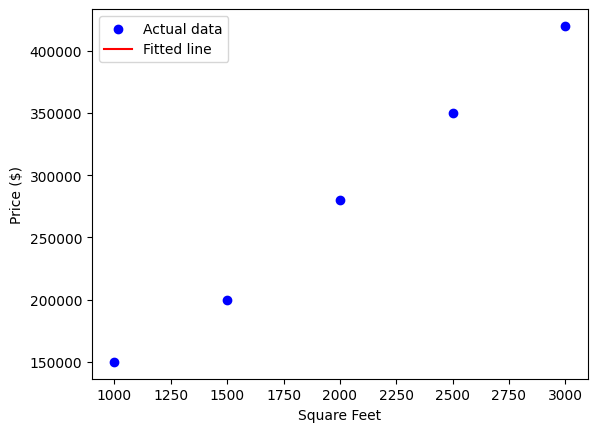

In [17]:
import numpy as np
import matplotlib.pyplot as plt

class LinearRegressionFromScratch:
    """Linear Regression implemented from scratch using NumPy."""

    def __init__(self, learning_rate=0.01, iterations=1000):
        # learning_rate: controls how big each step is during training
        # iterations: how many times we update our parameters
        self.learning_rate = learning_rate
        self.iterations = iterations
        self.theta0 = 0  # intercept (y-intercept of the line)
        self.theta1 = 0  # slope (steepness of the line)
        self.cost_history = []  # track cost over iterations

    def fit(self, X, y):
        """Train the model on data X and labels y."""
        m = len(X)  # number of training examples

        # Repeat the learning process for specified iterations
        for iteration in range(self.iterations):
            # Step 1: Make predictions using current parameters
            # y_pred = theta0 + theta1 * X
            y_pred = self.theta0 + self.theta1 * X

            # Step 2: Calculate errors (difference between predicted and actual)
            errors = y_pred - y

            # Step 3: Calculate cost (Mean Squared Error)
            # Cost = (1/2m) * sum(errors²)
            cost = (1 / (2 * m)) * np.sum(errors ** 2)
            self.cost_history.append(cost)

            # Step 4: Calculate gradients (direction and magnitude of change)
            # Gradient for theta0 = (1/m) * sum(errors)
            gradient_theta0 = (1 / m) * np.sum(errors)
            # Gradient for theta1 = (1/m) * sum(errors * X)
            gradient_theta1 = (1 / m) * np.sum(errors * X)

            # Step 5: Update parameters using gradients
            # Move in opposite direction of gradient to minimize cost
            self.theta0 -= self.learning_rate * gradient_theta0
            self.theta1 -= self.learning_rate * gradient_theta1

        return self

    def predict(self, X):
        """Make predictions on new data."""
        # Use learned parameters to predict: y = theta0 + theta1 * X
        return self.theta0 + self.theta1 * X

    def get_parameters(self):
        """Return learned parameters."""
        return {'intercept': self.theta0, 'slope': self.theta1}

# Example usage
if __name__ == '__main__':
    # Sample data: house sizes and prices
    X = np.array([1000, 1500, 2000, 2500, 3000])  # square feet
    y = np.array([150000, 200000, 280000, 350000, 420000])  # prices

    # Create and train model
    model = LinearRegressionFromScratch(learning_rate=0.00001, iterations=1000)
    model.fit(X, y)

    # Make predictions
    predictions = model.predict(X)

    # Print results
    print('Learned Parameters:')
    params = model.get_parameters()
    print(f'  Intercept (θ₀): {params["intercept"]:.2f}')
    print(f'  Slope (θ₁): {params["slope"]:.2f}')
    print(f'\nPredictions vs Actual:')
    for i in range(len(X)):
        print(f'  X={X[i]}: Predicted={predictions[i]:.0f}, Actual={y[i]}')

    # Visualize
    plt.scatter(X, y, color='blue', label='Actual data')
    plt.plot(X, predictions, color='red', label='Fitted line')
    plt.xlabel('Square Feet')
    plt.ylabel('Price ($)')
    plt.legend()
    plt.show()

In [18]:
import numpy as np

class LogisticRegressionFromScratch:
    def __init__(self, learning_rate=0.01, iterations=1000):
        self.lr = learning_rate
        self.iterations = iterations
        self.theta = None

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def fit(self, X, y):
        m, n = X.shape
        X = np.c_[np.ones(m), X]
        self.theta = np.zeros(n + 1)
        for _ in range(self.iterations):
            h = self.sigmoid(X @ self.theta)
            gradient = (1/m) * X.T @ (h - y)
            self.theta -= self.lr * gradient
        return self

    def predict(self, X):
        m = X.shape[0]
        X = np.c_[np.ones(m), X]
        return (self.sigmoid(X @ self.theta) >= 0.5).astype(int)

In [19]:
import numpy as np
from collections import Counter

class KNNFromScratch:
    def __init__(self, k=3):
        self.k = k
        self.X_train = None
        self.y_train = None

    def fit(self, X, y):
        """Store training data"""
        self.X_train = X
        self.y_train = y
        return self

    def euclidean_distance(self, x1, x2):
        """Calculate Euclidean distance"""
        return np.sqrt(np.sum((x1 - x2) ** 2))

    def predict(self, X):
        """Predict class for each test point"""
        predictions = [self._predict_single(x) for x in X]
        return np.array(predictions)

    def _predict_single(self, x):
        """Predict class for a single point"""
        # Compute distances to all training points
        distances = [self.euclidean_distance(x, x_train) for x_train in self.X_train]

        # Get indices of k nearest neighbors
        k_indices = np.argsort(distances)[:self.k]

        # Get labels of k nearest neighbors
        k_nearest_labels = [self.y_train[i] for i in k_indices]

        # Return most common label
        most_common = Counter(k_nearest_labels).most_common(1)
        return most_common[0][0]

# Example
X_train = np.array([[1.4, 0.2], [1.3, 0.3], [4.5, 1.5], [4.7, 1.4], [6.0, 2.5]])
y_train = np.array([0, 0, 1, 1, 2])
X_test = np.array([[4.6, 1.4]])

model = KNNFromScratch(k=3)
model.fit(X_train, y_train)
predictions = model.predict(X_test)
print(f'Prediction: {predictions[0]}')

Prediction: 1


Converged at iteration 2

Final Inertia: 286.18

Centroids:
  Cluster 0: [7.90454712 2.14006205]
  Cluster 1: [1.86432437 1.9279826 ]
  Cluster 2: [5.12894675 8.00084575]


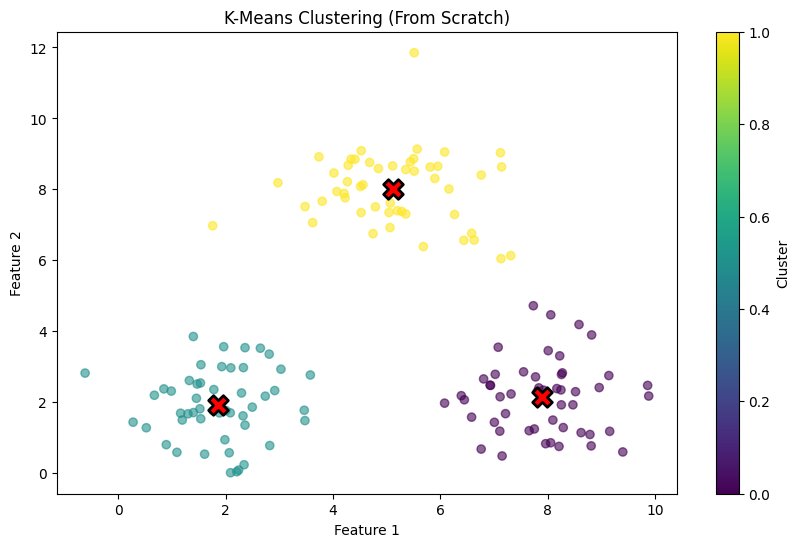

In [20]:
import numpy as np
import matplotlib.pyplot as plt

class KMeansFromScratch:
    """K-Means clustering implemented from scratch."""

    def __init__(self, n_clusters=3, max_iters=100, random_state=42):
        self.n_clusters = n_clusters
        self.max_iters = max_iters
        self.random_state = random_state
        self.centroids = None
        self.labels = None
        self.inertia = None

    def fit(self, X):
        """Fit K-Means to data X."""
        np.random.seed(self.random_state)

        # Step 1: Initialize centroids randomly
        # Pick K random points from data as initial centroids
        random_indices = np.random.choice(len(X), self.n_clusters, replace=False)
        self.centroids = X[random_indices].copy()

        # Iterate until convergence or max iterations
        for iteration in range(self.max_iters):
            # Step 2: Assignment - assign each point to nearest centroid
            self.labels = self._assign_clusters(X)

            # Step 3: Update - recalculate centroids
            new_centroids = self._update_centroids(X)

            # Check for convergence (centroids don't change)
            if np.allclose(self.centroids, new_centroids):
                print(f'Converged at iteration {iteration + 1}')
                break

            self.centroids = new_centroids

        # Calculate final inertia (within-cluster sum of squares)
        self.inertia = self._calculate_inertia(X)

        return self

    def _assign_clusters(self, X):
        """Assign each point to the nearest centroid."""
        # Calculate distance from each point to each centroid
        distances = np.zeros((len(X), self.n_clusters))

        for k in range(self.n_clusters):
            # Euclidean distance: sqrt(sum((x - centroid)^2))
            distances[:, k] = np.sqrt(np.sum((X - self.centroids[k]) ** 2, axis=1))

        # Assign to nearest centroid (minimum distance)
        return np.argmin(distances, axis=1)

    def _update_centroids(self, X):
        """Update centroids as mean of assigned points."""
        new_centroids = np.zeros((self.n_clusters, X.shape[1]))

        for k in range(self.n_clusters):
            # Find all points assigned to cluster k
            cluster_points = X[self.labels == k]

            if len(cluster_points) > 0:
                # Centroid = mean of all points in cluster
                new_centroids[k] = cluster_points.mean(axis=0)
            else:
                # If cluster is empty, keep old centroid
                new_centroids[k] = self.centroids[k]

        return new_centroids

    def _calculate_inertia(self, X):
        """Calculate within-cluster sum of squares."""
        inertia = 0
        for k in range(self.n_clusters):
            cluster_points = X[self.labels == k]
            if len(cluster_points) > 0:
                # Sum of squared distances to centroid
                inertia += np.sum((cluster_points - self.centroids[k]) ** 2)
        return inertia

    def predict(self, X):
        """Predict cluster for new data."""
        return self._assign_clusters(X)

# Example usage
if __name__ == '__main__':
    # Generate sample data: 3 clusters
    np.random.seed(42)
    cluster1 = np.random.randn(50, 2) + [2, 2]
    cluster2 = np.random.randn(50, 2) + [8, 2]
    cluster3 = np.random.randn(50, 2) + [5, 8]
    X = np.vstack([cluster1, cluster2, cluster3])

    # Fit K-Means
    kmeans = KMeansFromScratch(n_clusters=3, max_iters=100)
    kmeans.fit(X)

    # Results
    print(f'\nFinal Inertia: {kmeans.inertia:.2f}')
    print(f'\nCentroids:')
    for i, centroid in enumerate(kmeans.centroids):
        print(f'  Cluster {i}: {centroid}')

    # Visualize
    plt.figure(figsize=(10, 6))
    plt.scatter(X[:, 0], X[:, 1], c=kmeans.labels, cmap='viridis', alpha=0.6)
    plt.scatter(kmeans.centroids[:, 0], kmeans.centroids[:, 1],
                c='red', marker='X', s=200, edgecolors='black', linewidths=2)
    plt.title('K-Means Clustering (From Scratch)')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.colorbar(label='Cluster')
    plt.show()

In [21]:
import numpy as np

class GaussianNaiveBayes:
    """Gaussian Naive Bayes classifier from scratch."""

    def __init__(self):
        self.classes = None
        self.class_priors = {}  # P(C)
        self.means = {}         # μ for each feature per class
        self.variances = {}     # σ² for each feature per class

    def fit(self, X, y):
        """Train the Naive Bayes classifier."""
        self.classes = np.unique(y)
        n_samples = len(y)

        # Calculate priors and parameters for each class
        for c in self.classes:
            # Get all samples belonging to class c
            X_c = X[y == c]

            # Prior: P(C) = count(C) / total_samples
            self.class_priors[c] = len(X_c) / n_samples

            # For each feature, calculate mean and variance
            # Assumes features follow Gaussian distribution
            self.means[c] = X_c.mean(axis=0)
            self.variances[c] = X_c.var(axis=0)

        return self

    def _calculate_likelihood(self, x, mean, var):
        """Calculate Gaussian probability density."""
        # Gaussian PDF: (1/√(2πσ²)) * exp(-(x-μ)²/(2σ²))
        eps = 1e-6  # Small constant to avoid division by zero
        coeff = 1.0 / np.sqrt(2 * np.pi * var + eps)
        exponent = np.exp(-((x - mean) ** 2) / (2 * var + eps))
        return coeff * exponent

    def _calculate_class_probability(self, x, c):
        """Calculate P(C|X) ∝ P(C) * P(X|C)."""
        # Start with prior probability
        log_prob = np.log(self.class_priors[c])

        # Multiply by likelihood of each feature (use log for stability)
        # P(X|C) = P(x₁|C) * P(x₂|C) * ... * P(xₙ|C)
        for i in range(len(x)):
            likelihood = self._calculate_likelihood(
                x[i],
                self.means[c][i],
                self.variances[c][i]
            )
            log_prob += np.log(likelihood + 1e-10)  # Add small constant to avoid log(0)

        return log_prob

    def predict(self, X):
        """Predict class for each sample."""
        predictions = []

        for x in X:
            # Calculate probability for each class
            class_probs = {}
            for c in self.classes:
                class_probs[c] = self._calculate_class_probability(x, c)

            # Choose class with maximum probability
            predicted_class = max(class_probs, key=class_probs.get)
            predictions.append(predicted_class)

        return np.array(predictions)

    def predict_proba(self, X):
        """Predict probability for each class."""
        probabilities = []

        for x in X:
            # Calculate log probability for each class
            log_probs = []
            for c in self.classes:
                log_probs.append(self._calculate_class_probability(x, c))

            # Convert log probabilities to probabilities (softmax)
            log_probs = np.array(log_probs)
            # Subtract max for numerical stability
            log_probs = log_probs - np.max(log_probs)
            probs = np.exp(log_probs)
            probs = probs / np.sum(probs)  # Normalize

            probabilities.append(probs)

        return np.array(probabilities)

# Example usage
if __name__ == '__main__':
    # Generate sample data: 2 classes with different means
    np.random.seed(42)

    # Class 0: mean=[2, 2]
    X_class0 = np.random.randn(50, 2) + [2, 2]
    y_class0 = np.zeros(50)

    # Class 1: mean=[5, 5]
    X_class1 = np.random.randn(50, 2) + [5, 5]
    y_class1 = np.ones(50)

    # Combine data
    X = np.vstack([X_class0, X_class1])
    y = np.hstack([y_class0, y_class1])

    # Train model
    nb = GaussianNaiveBayes()
    nb.fit(X, y)

    # Test predictions
    test_samples = np.array([[2, 2], [5, 5], [3.5, 3.5]])
    predictions = nb.predict(test_samples)
    probabilities = nb.predict_proba(test_samples)

    print('Predictions:')
    for i, (sample, pred, prob) in enumerate(zip(test_samples, predictions, probabilities)):
        print(f'  Sample {sample}: Class {int(pred)}, Probabilities: {prob}')

    print(f'\nClass Priors: {nb.class_priors}')
    print(f'Class 0 means: {nb.means[0.0]}')
    print(f'Class 1 means: {nb.means[1.0]}')


Predictions:
  Sample [2. 2.]: Class 0, Probabilities: [9.99971569e-01 2.84309128e-05]
  Sample [5. 5.]: Class 1, Probabilities: [5.70120573e-06 9.99994299e-01]
  Sample [3.5 3.5]: Class 1, Probabilities: [0.3652783 0.6347217]

Class Priors: {np.float64(0.0): 0.5, np.float64(1.0): 0.5}
Class 0 means: [1.86432437 1.9279826 ]
Class 1 means: [4.90454712 5.14006205]


In [22]:
import numpy as np
from collections import Counter

class Node:
    def __init__(self, feature=None, threshold=None, left=None, right=None, value=None):
        self.feature = feature      # Feature index to split on
        self.threshold = threshold  # Threshold value for split
        self.left = left           # Left child node
        self.right = right         # Right child node
        self.value = value         # Prediction value (for leaf nodes)

class DecisionTreeFromScratch:
    def __init__(self, max_depth=10, min_samples_split=2):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.root = None

    def gini_impurity(self, y):
        """Calculate Gini impurity"""
        counter = Counter(y)
        impurity = 1.0
        for count in counter.values():
            prob = count / len(y)
            impurity -= prob ** 2
        return impurity

    def split(self, X, y, feature, threshold):
        """Split dataset based on feature and threshold"""
        left_mask = X[:, feature] <= threshold
        right_mask = ~left_mask
        return X[left_mask], X[right_mask], y[left_mask], y[right_mask]

    def best_split(self, X, y):
        """Find best feature and threshold to split on"""
        best_gain = -1
        best_feature = None
        best_threshold = None

        parent_impurity = self.gini_impurity(y)
        n_samples = len(y)

        # Try each feature
        for feature in range(X.shape[1]):
            thresholds = np.unique(X[:, feature])

            # Try each threshold
            for threshold in thresholds:
                X_left, X_right, y_left, y_right = self.split(X, y, feature, threshold)

                if len(y_left) == 0 or len(y_right) == 0:
                    continue

                # Calculate weighted impurity
                n_left, n_right = len(y_left), len(y_right)
                weighted_impurity = (n_left/n_samples) * self.gini_impurity(y_left) + \
                                   (n_right/n_samples) * self.gini_impurity(y_right)

                # Calculate information gain
                gain = parent_impurity - weighted_impurity

                # Calculate information gain
                gain = parent_impurity - weighted_impurity

                if gain > best_gain:
                    best_gain = gain
                    best_feature = feature
                    best_threshold = threshold

        return best_feature, best_threshold

    def build_tree(self, X, y, depth=0):
        """Recursively build the decision tree"""
        n_samples, n_features = X.shape
        n_classes = len(np.unique(y))

        # Stopping criteria
        if depth >= self.max_depth or n_samples < self.min_samples_split or n_classes == 1:
            leaf_value = Counter(y).most_common(1)[0][0]
            return Node(value=leaf_value)

        # Find best split
        feature, threshold = self.best_split(X, y)

        if feature is None:
            leaf_value = Counter(y).most_common(1)[0][0]
            return Node(value=leaf_value)

        # Split and recurse
        X_left, X_right, y_left, y_right = self.split(X, y, feature, threshold)
        left_child = self.build_tree(X_left, y_left, depth + 1)
        right_child = self.build_tree(X_right, y_right, depth + 1)

        return Node(feature=feature, threshold=threshold, left=left_child, right=right_child)

    def fit(self, X, y):
        """Train the decision tree"""
        self.root = self.build_tree(X, y)
        return self

    def predict_single(self, x, node):
        """Predict single sample"""
        if node.value is not None:
            return node.value

        if x[node.feature] <= node.threshold:
            return self.predict_single(x, node.left)
        else:
            return self.predict_single(x, node.right)

    def predict(self, X):
        """Predict multiple samples"""
        return np.array([self.predict_single(x, self.root) for x in X])

# Example
X = np.array([[2.5, 1], [3.5, 2], [1.5, 1], [4.5, 3], [2, 2]])
y = np.array([0, 0, 1, 0, 1])

model = DecisionTreeFromScratch(max_depth=3)
model.fit(X, y)
predictions = model.predict(X)
print(f'Predictions: {predictions}')
print(f'Actual: {y}')

Predictions: [0 0 1 0 1]
Actual: [0 0 1 0 1]


In [23]:
import numpy as np

class SVMModeller:
    def __init__(self, learning_rate=0.001, lambda_param=0.01, n_iters=1000):
        self.lr = learning_rate
        self.lambda_param = lambda_param
        self.n_iters = n_iters
        self.w = None
        self.b = None

    def fit(self, X, y):
        n_samples, n_features = X.shape
        y_ = np.where(y <= 0, -1, 1)
        self.w = np.zeros(n_features)
        self.b = 0

        for _ in range(self.n_iters):
            for idx, x_i in enumerate(X):
                condition = y_[idx] * (np.dot(x_i, self.w) - self.b) >= 1
                if condition:
                    # Gradient of Regularization term: lambda * w
                    self.w -= self.lr * (2 * self.lambda_param * self.w)
                else:
                    # Gradient of (Regularization + Hinge Loss)
                    self.w -= self.lr * (2 * self.lambda_param * self.w - np.dot(x_i, y_[idx]))
                    self.b -= self.lr * y_[idx]

    def predict(self, X):
        return np.sign(np.dot(X, self.w) - self.b)

In [24]:
import numpy as np

class NeuralNetwork:
    def __init__(self, input_size, hidden_size, output_size):
        # Initialize weights with small random values
        self.W1 = np.random.randn(input_size, hidden_size) * 0.01
        self.b1 = np.zeros((1, hidden_size))
        self.W2 = np.random.randn(hidden_size, output_size) * 0.01
        self.b2 = np.zeros((1, output_size))

    def relu(self, z):
        """ReLU activation function"""
        return np.maximum(0, z)

    def relu_derivative(self, z):
        """Derivative of ReLU"""
        return (z > 0).astype(float)

    def softmax(self, z):
        """Softmax for output layer"""
        exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
        return exp_z / np.sum(exp_z, axis=1, keepdims=True)

    def forward(self, X):
        """Forward propagation"""
        # Hidden layer
        self.z1 = np.dot(X, self.W1) + self.b1
        self.a1 = self.relu(self.z1)

        # Output layer
        self.z2 = np.dot(self.a1, self.W2) + self.b2
        self.a2 = self.softmax(self.z2)

        return self.a2

    def backward(self, X, y, learning_rate=0.01):
        """Backpropagation"""
        m = X.shape[0]

        # Output layer gradients
        dz2 = self.a2 - y
        dW2 = np.dot(self.a1.T, dz2) / m
        db2 = np.sum(dz2, axis=0, keepdims=True) / m

        # Hidden layer gradients
        da1 = np.dot(dz2, self.W2.T)
        dz1 = da1 * self.relu_derivative(self.z1)
        dW1 = np.dot(X.T, dz1) / m
        db1 = np.sum(dz1, axis=0, keepdims=True) / m

        # Update weights
        self.W2 -= learning_rate * dW2
        self.b2 -= learning_rate * db2
        self.W1 -= learning_rate * dW1
        self.b1 -= learning_rate * db1

    def train(self, X, y, epochs=1000, learning_rate=0.01):
        """Training loop"""
        for epoch in range(epochs):
            # Forward pass
            predictions = self.forward(X)

            # Compute loss
            loss = -np.mean(np.sum(y * np.log(predictions + 1e-8), axis=1))

            # Backward pass
            self.backward(X, y, learning_rate)

            if epoch % 100 == 0:
                print(f'Epoch {epoch}, Loss: {loss:.4f}')

    def predict(self, X):
        """Make predictions"""
        probs = self.forward(X)
        return np.argmax(probs, axis=1)

# Example usage
if __name__ == '__main__':
    # Generate sample data
    np.random.seed(42)
    X = np.random.randn(100, 20)  # 100 samples, 20 features
    y = np.eye(3)[np.random.randint(0, 3, 100)]  # 3 classes, one-hot encoded

    # Create and train network
    nn = NeuralNetwork(input_size=20, hidden_size=10, output_size=3)
    nn.train(X, y, epochs=500, learning_rate=0.1)

    # Make predictions
    predictions = nn.predict(X)
    accuracy = np.mean(predictions == np.argmax(y, axis=1))
    print(f'Training Accuracy: {accuracy:.2%}')

Epoch 0, Loss: 1.0986
Epoch 100, Loss: 1.0812
Epoch 200, Loss: 0.9313
Epoch 300, Loss: 0.6162
Epoch 400, Loss: 0.4107
Training Accuracy: 94.00%


In [25]:
import numpy as np

class SimpleCNN:
    def __init__(self):
        # Initialize a simple 3x3 filter for edge detection
        self.filter = np.array([[-1, -1, -1],
                               [0, 0, 0],
                               [1, 1, 1]], dtype=float)

    def convolve2d(self, image, kernel, stride=1, padding=0):
        """
        Perform 2D convolution
        image: input image (H x W)
        kernel: filter (K x K)
        """
        if padding > 0:
            image = np.pad(image, padding, mode='constant')

        H, W = image.shape
        K = kernel.shape[0]

        # Output dimensions
        out_H = (H - K) // stride + 1
        out_W = (W - K) // stride + 1

        output = np.zeros((out_H, out_W))

        # Slide filter over image
        for i in range(0, out_H):
            for j in range(0, out_W):
                # Extract region
                region = image[i*stride:i*stride+K, j*stride:j*stride+K]
                # Element-wise multiplication and sum
                output[i, j] = np.sum(region * kernel)

        return output

    def relu(self, x):
        """ReLU activation"""
        return np.maximum(0, x)

    def max_pool(self, feature_map, pool_size=2, stride=2):
        """
        Max pooling operation
        """
        H, W = feature_map.shape
        out_H = (H - pool_size) // stride + 1
        out_W = (W - pool_size) // stride + 1

        output = np.zeros((out_H, out_W))

        for i in range(out_H):
            for j in range(out_W):
                region = feature_map[i*stride:i*stride+pool_size,
                                    j*stride:j*stride+pool_size]
                output[i, j] = np.max(region)

        return output

    def forward(self, image):
        """
        Forward pass through CNN
        """
        # Convolution
        conv_output = self.convolve2d(image, self.filter, padding=1)
        print(f"After convolution: {conv_output.shape}")

        # Activation
        activated = self.relu(conv_output)
        print(f"After ReLU: {activated.shape}")

        # Pooling
        pooled = self.max_pool(activated)
        print(f"After pooling: {pooled.shape}")

        return pooled

# Example usage
if __name__ == '__main__':
    # Create sample 8x8 grayscale image
    image = np.random.rand(8, 8) * 255
    print(f"Input image shape: {image.shape}")

    # Create CNN and process
    cnn = SimpleCNN()
    output = cnn.forward(image)

    print(f"\nFinal output shape: {output.shape}")
    print(f"Output values:\n{output}")

Input image shape: (8, 8)
After convolution: (8, 8)
After ReLU: (8, 8)
After pooling: (4, 4)

Final output shape: (4, 4)
Output values:
[[187.10874368 444.27625233 414.57479812 388.98779227]
 [231.6007103   99.7784052   21.80912396  29.4040645 ]
 [  0.           0.         310.64954932  54.74063542]
 [189.21441603 122.47169949 325.74925287 330.64380197]]


In [26]:
import numpy as np

class SimpleRNN:
    def __init__(self, input_size, hidden_size, output_size):
        # Initialize weights
        self.hidden_size = hidden_size

        # Input to hidden
        self.Wxh = np.random.randn(hidden_size, input_size) * 0.01
        # Hidden to hidden (recurrent connection)
        self.Whh = np.random.randn(hidden_size, hidden_size) * 0.01
        # Hidden to output
        self.Why = np.random.randn(output_size, hidden_size) * 0.01
        # Biases
        self.bh = np.zeros((hidden_size, 1))
        self.by = np.zeros((output_size, 1))

    def forward(self, inputs, h_prev):
        """
        Forward pass through RNN
        inputs: list of input vectors (one per time step)
        h_prev: previous hidden state
        """
        xs, hs, ys, ps = {}, {}, {}, {}
        hs[-1] = np.copy(h_prev)

        # Forward pass through time
        for t, x in enumerate(inputs):
            xs[t] = x
            # Hidden state update
            hs[t] = np.tanh(np.dot(self.Wxh, xs[t]) +
                           np.dot(self.Whh, hs[t-1]) + self.bh)
            # Output
            ys[t] = np.dot(self.Why, hs[t]) + self.by
            # Softmax probabilities
            ps[t] = np.exp(ys[t]) / np.sum(np.exp(ys[t]))

        return xs, hs, ys, ps

    def backward(self, xs, hs, ps, targets):
        """
        Backward pass (BPTT)
        """
        # Initialize gradients
        dWxh = np.zeros_like(self.Wxh)
        dWhh = np.zeros_like(self.Whh)
        dWhy = np.zeros_like(self.Why)
        dbh = np.zeros_like(self.bh)
        dby = np.zeros_like(self.by)
        dh_next = np.zeros_like(hs[0])

        # Backward pass through time
        for t in reversed(range(len(xs))):
            # Output layer gradient
            dy = np.copy(ps[t])
            dy[targets[t]] -= 1  # Softmax gradient

            dWhy += np.dot(dy, hs[t].T)
            dby += dy

            # Hidden layer gradient
            dh = np.dot(self.Why.T, dy) + dh_next
            dhraw = (1 - hs[t] * hs[t]) * dh  # tanh gradient

            dbh += dhraw
            dWxh += np.dot(dhraw, xs[t].T)
            dWhh += np.dot(dhraw, hs[t-1].T)
            dh_next = np.dot(self.Whh.T, dhraw)

        # Clip gradients to prevent exploding gradients
        for dparam in [dWxh, dWhh, dWhy, dbh, dby]:
            np.clip(dparam, -5, 5, out=dparam)

        return dWxh, dWhh, dWhy, dbh, dby

    def sample(self, h, seed_ix, n):
        """
        Generate sequence by sampling from the model
        """
        x = np.zeros((self.Wxh.shape[1], 1))
        x[seed_ix] = 1
        ixes = []

        for t in range(n):
            h = np.tanh(np.dot(self.Wxh, x) + np.dot(self.Whh, h) + self.bh)
            y = np.dot(self.Why, h) + self.by
            p = np.exp(y) / np.sum(np.exp(y))
            ix = np.random.choice(range(len(p)), p=p.ravel())
            x = np.zeros((self.Wxh.shape[1], 1))
            x[ix] = 1
            ixes.append(ix)

        return ixes

# Example usage
if __name__ == '__main__':
    # Simple character-level example
    data = 'hello world'
    chars = list(set(data))
    data_size, vocab_size = len(data), len(chars)

    char_to_ix = {ch: i for i, ch in enumerate(chars)}
    ix_to_char = {i: ch for i, ch in enumerate(chars)}

    # Create RNN
    rnn = SimpleRNN(vocab_size, hidden_size=100, output_size=vocab_size)

    print(f"Vocabulary: {chars}")
    print(f"Vocabulary size: {vocab_size}")
    print(f"Data: {data}")

Vocabulary: ['e', ' ', 'l', 'o', 'w', 'd', 'r', 'h']
Vocabulary size: 8
Data: hello world


In [27]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models


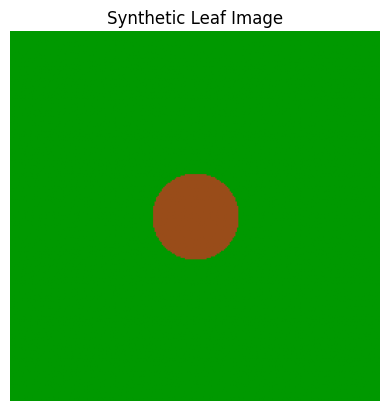

In [28]:
img = np.zeros((256,256,3))
img[:,:,1] = 0.6

for i in range(256):
    for j in range(256):
        if (i-128)**2 + (j-128)**2 < 30**2:
            img[i,j] = [0.6,0.3,0.1]

plt.figure()
plt.imshow(img)
plt.title('Synthetic Leaf Image')
plt.axis('off')
plt.show()

In [29]:
def unet_model():
    inputs = layers.Input((256,256,3))

    c1 = layers.Conv2D(32,(3,3),activation='relu',padding='same')(inputs)
    c1 = layers.Conv2D(32,(3,3),activation='relu',padding='same')(c1)
    p1 = layers.MaxPooling2D((2,2))(c1)

    c2 = layers.Conv2D(64,(3,3),activation='relu',padding='same')(p1)
    c2 = layers.Conv2D(64,(3,3),activation='relu',padding='same')(c2)
    p2 = layers.MaxPooling2D((2,2))(c2)

    b = layers.Conv2D(128,(3,3),activation='relu',padding='same')(p2)

    u1 = layers.UpSampling2D((2,2))(b)
    u1 = layers.concatenate([u1,c2])
    c3 = layers.Conv2D(64,(3,3),activation='relu',padding='same')(u1)

    u2 = layers.UpSampling2D((2,2))(c3)
    u2 = layers.concatenate([u2,c1])
    c4 = layers.Conv2D(32,(3,3),activation='relu',padding='same')(u2)

    outputs = layers.Conv2D(1,(1,1),activation='sigmoid')(c4)

    return models.Model(inputs, outputs)

model = unet_model()
model.summary()

Model: "functional_10"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │        896 │ input_layer_3[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 256, 256,  │      9,248 │ conv2d_1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 128, 128,  │          0 │ conv2d_2[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │     18,496 │ max_pooling2d_1[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 128, 128,  │     36,928 │ conv2d_3[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 64, 64,    │          0 │ conv2d_4[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 64, 64,    │     73,856 │ max_pooling2d_2[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, 128, 128,  │          0 │ conv2d_5[0][0]    │
│ (UpSampling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 128, 128,  │          0 │ up_sampling2d[0]… │
│ (Concatenate)       │ 192)              │            │ conv2d_4[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 128, 128,  │    110,656 │ concatenate[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_1     │ (None, 256, 256,  │          0 │ conv2d_6[0][0]    │
│ (UpSampling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 256, 256,  │          0 │ up_sampling2d_1[… │
│ (Concatenate)       │ 96)               │            │ conv2d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 256, 256,  │     27,680 │ concatenate_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 256, 256,  │         33 │ conv2d_7[0][0]    │
│                     │ 1)                │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 277,793 (1.06 MB)

 Trainable params: 277,793 (1.06 MB)

 Non-trainable params: 0 (0.00 B)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 524ms/step


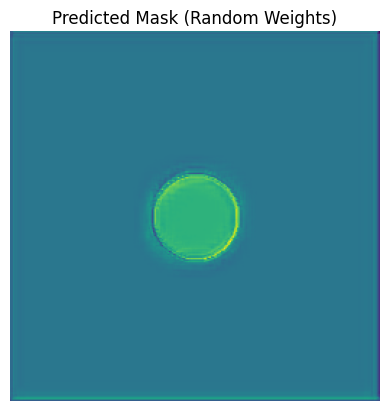

In [30]:
img_input = np.expand_dims(img,axis=0)
prediction = model.predict(img_input)

plt.figure()
plt.imshow(prediction[0,:,:,0])
plt.title('Predicted Mask (Random Weights)')
plt.axis('off')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 469ms/step


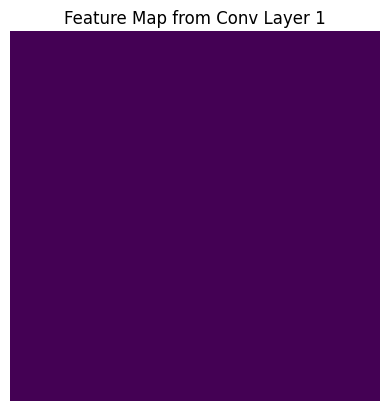

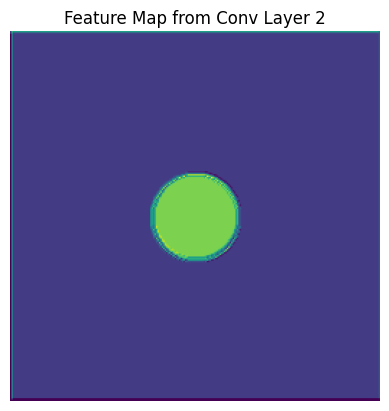

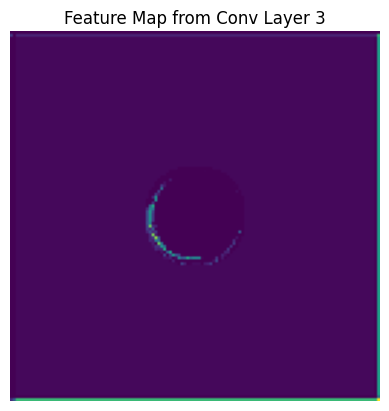

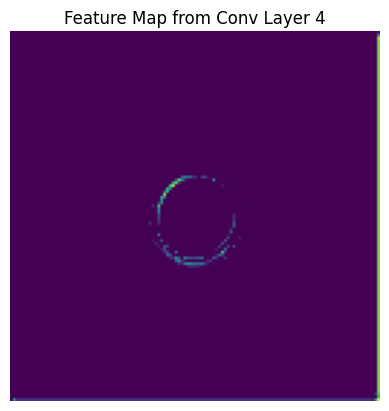

In [31]:
layer_outputs = [layer.output for layer in model.layers if isinstance(layer, tf.keras.layers.Conv2D)]
feature_model = models.Model(inputs=model.input, outputs=layer_outputs)

features = feature_model.predict(img_input)

for i in range(min(4,len(features))):
    plt.figure()
    plt.imshow(features[i][0,:,:,0])
    plt.title(f'Feature Map from Conv Layer {i+1}')
    plt.axis('off')
    plt.show()

In [32]:
import seaborn as sns
import pandas as pd

# Load dataset
df = sns.load_dataset('diamonds')

print(df.head())
print(f"\nPrice Statistics:\n{df['price'].describe()}")

   carat      cut color clarity  depth  table  price     x     y     z
0   0.23    Ideal     E     SI2   61.5   55.0    326  3.95  3.98  2.43
1   0.21  Premium     E     SI1   59.8   61.0    326  3.89  3.84  2.31
2   0.23     Good     E     VS1   56.9   65.0    327  4.05  4.07  2.31
3   0.29  Premium     I     VS2   62.4   58.0    334  4.20  4.23  2.63
4   0.31     Good     J     SI2   63.3   58.0    335  4.34  4.35  2.75

Price Statistics:
count    53940.000000
mean      3932.799722
std       3989.439738
min        326.000000
25%        950.000000
50%       2401.000000
75%       5324.250000
max      18823.000000
Name: price, dtype: float64


In [33]:
from sklearn.datasets import load_breast_cancer
import pandas as pd

# Load dataset
cancer = load_breast_cancer()
X = cancer.data
y = cancer.target

# Convert to DataFrame
df = pd.DataFrame(X, columns=cancer.feature_names)
df['diagnosis'] = cancer.target_names[y]

print(df.head())

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimeter  worst area  \
0             

In [34]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train model
model = LogisticRegression(max_iter=5000)
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred))

Logistic Regression Accuracy: 0.9736842105263158
